In [1]:
# taken from https://docs.langchain.com/oss/python/integrations/chat/openai - instantiation section
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

load_dotenv()  # take environment variables from .env.

if os.environ['OPENAI_API_KEY']:
    print("Open API Key is set")
else:
    raise ValueError("OPENAI_API_KEY is not set in the environment variables.")

Open API Key is set


In [3]:
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(model="gpt-5.4-nano-2026-03-17")
# llm.invoke("I want to know the meaning of life").content
llm.invoke([HumanMessage(content="I want to know the meaning of life")]).content

'The meaning of life is one of those questions with no single, universally proven answer—but there are a few common ways people approach it. Here are some of the most useful lenses; you can tell me which one fits you best.\n\n### 1) Meaning as **purpose**\nSome people find meaning by pursuing goals that matter to them (family, work, creativity, learning, service).  \n**Question to try:** *What would make a good life for me, even if no one else agreed?*\n\n### 2) Meaning as **relationships**\nMany people experience meaning through love, friendship, community, and being understood.  \n**Question:** *Who do I want to be closer to—and what kind of person do I want to be for them?*\n\n### 3) Meaning as **growth and contribution**\nA common view is that meaning comes from becoming more capable and helping others—reducing suffering, improving life, or sharing knowledge.  \n**Question:** *Where can I contribute in a way that feels honest and effective?*\n\n### 4) Meaning as **acceptance and pr

In [5]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):
    messages_manual: List
    messages_auto: Annotated[List, add]

In [11]:
from langchain_core.messages import AIMessage

def create_post(state: graph_schema) -> graph_schema:
    message_manual = state['messages_manual']

    response_manual = llm.invoke(message_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    
    state['messages_manual'] = message_manual + [response_manual_ai]

    return state

def curate_post(state: graph_schema) -> graph_schema:    
    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    reponse_manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [reponse_manual_ai]

    return state

In [12]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()

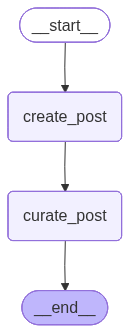

In [13]:
from IPython.display import Image, display

# You can see errors with the following command
Image(messages_graph.get_graph().draw_mermaid_png())


In [14]:
messages_graph.invoke({
    "messages_manual": [HumanMessage(content="I want to know the meaning of life")]
})

{'messages_manual': [HumanMessage(content='I want to know the meaning of life', additional_kwargs={}, response_metadata={}),
  AIMessage(content='The “meaning of life” is one of those questions where there isn’t a single universally agreed answer—but there *are* a few well-supported ways people make sense of it. Here are some perspectives you can consider:\n\n### 1) Meaning as purpose (you create it)\nMany people—especially in existential philosophy—argue that life doesn’t come with a built-in meaning; you create it through your choices, values, work, relationships, and commitments.  \n**Question to ask:** *What kind of person do I want to be, and what would that look like in my daily actions?*\n\n### 2) Meaning as contribution (you matter to others)\nAnother common view is that meaning comes from helping—love, care, community, making things better for someone.  \n**Question:** *Who benefits from my existence, and how can I increase that benefit?*\n\n### 3) Meaning as growth (you learn

In [ ]:
#Using pprint
import pprint
pprint.pprint(
    messages_graph.invoke({
        "messages_manual": [HumanMessage(content="I want to know the meaning of life")]
    })
)

NameError: name 'message_graph' is not defined